<a href="https://colab.research.google.com/github/Solo7602/IIAS/blob/lab5/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

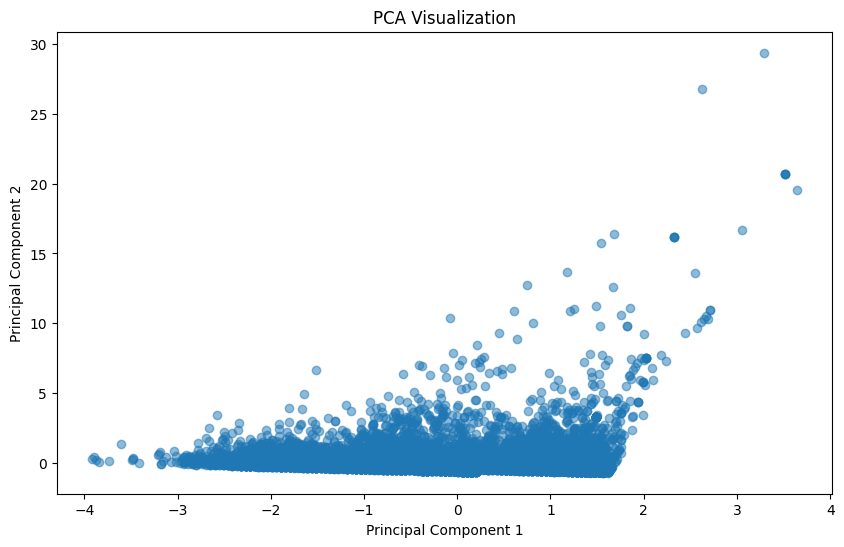

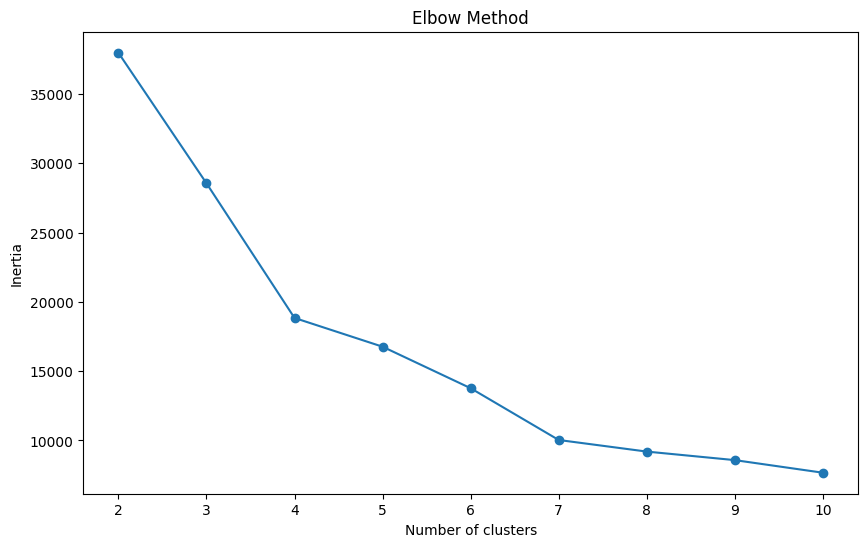

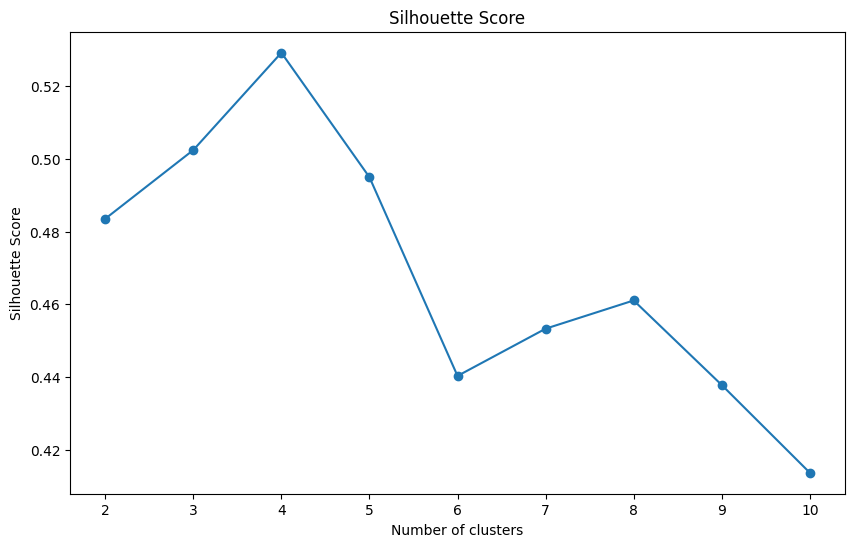

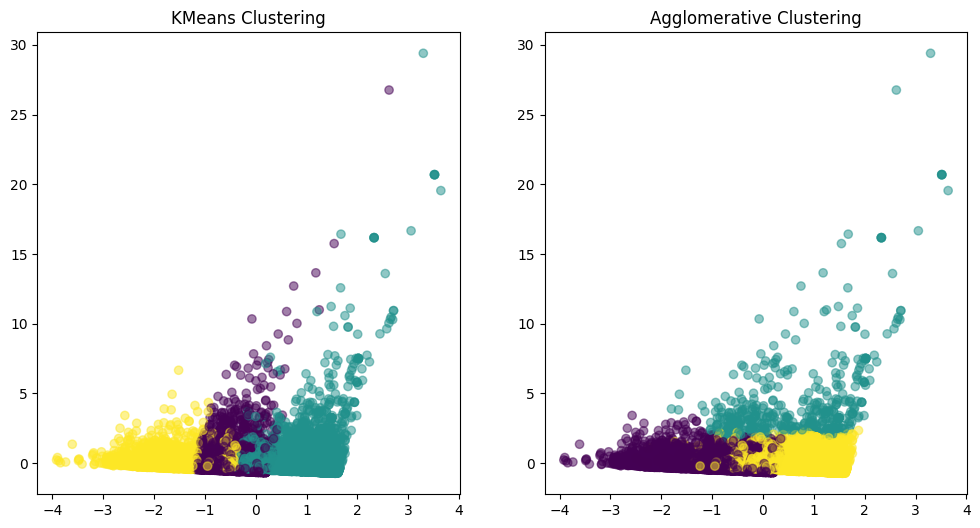

Silhouette Score (KMeans): 0.5024632163748886
Silhouette Score (Agglomerative): 0.5048581668259328
                      Age  Sex_Male  Comment_Length
Cluster_KMeans                                     
0               27.721068   0.00000       66.042237
1               28.584050   1.00000       69.697713
2               57.650818   0.06807       51.815277


<ipython-input-1-bdf56049a78b>:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cluster_KMeans'] = kmeans_labels


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Загрузка данных
data_long = pd.read_csv('10k_dataset_processed_final_with_ageGroup.csv')

data = data_long.head(20000)

# Выбор признаков
features = data[['Age', 'Sex_Male', 'Comment_Length']]

# Стандартизация данных
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Применение PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# Визуализация
plt.figure(figsize=(10, 6))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization')
plt.show()

# Метод локтя
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Коэффициент силуэта
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    silhouette_scores.append(silhouette_score(scaled_features, labels))

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_features)

# Агломеративная кластеризация
agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(scaled_features)

# Визуализация кластеров
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.5)
plt.title('KMeans Clustering')

plt.subplot(1, 2, 2)
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=agg_labels, cmap='viridis', alpha=0.5)
plt.title('Agglomerative Clustering')
plt.show()

# Оценка качества
kmeans_score = silhouette_score(scaled_features, kmeans_labels)
agg_score = silhouette_score(scaled_features, agg_labels)

print(f'Silhouette Score (KMeans): {kmeans_score}')
print(f'Silhouette Score (Agglomerative): {agg_score}')

# Анализ кластеров
data['Cluster_KMeans'] = kmeans_labels
cluster_means = data.groupby('Cluster_KMeans')[['Age', 'Sex_Male', 'Comment_Length']].mean()
print(cluster_means)